In [ ]:
#TODO: Pass all of this into separated functions -> Cleaner to work with;

In [ ]:
import numpy as np
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from db_reader import dataframe_creator
import pandas as pd
import numpy as np
from transformations import nature_encode
from plots import plot_heatmap
from utils import read_json
from models_opt import OptimizeRegressor
import seaborn as sns
import matplotlib.pyplot as plt

: 

# 1. Data Cleaning

### 1.1 Load Data

Os dados devem ser carregados de uma base de dados, preferencialmente SQLite. Para isso, uma função de conexão entre a Base de Dados e o Notebook deve ser feita. A mesma pode igualmente ser implementada em uma função a parte ou em uma célula do notebook;

In [2]:
df = dataframe_creator();

Connected to SQLite Version 2.6.0


In [ ]:
#TODO: Download dataset from Kagglehub
#Comment: There are about 47 files still missing for download
#TODO: Create function that saves the csv -> SQLite into SQLite; 

# pip install kagglehub to be able to run below lines
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "prefecture_code.csv"
prefecture_code_data = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"nishiodens/japan-real-estate-transaction-prices",file_path) # download dataset as pandas dataframe

print(prefecture_code_data.head())

   Code JpName    EnName
0     1    北海道  Hokkaido
1     2    青森県   Aomori 
2     3    岩手県    Iwate 
3     4    宮城県   Miyagi 
4     5    秋田県    Akita 


### 1.2 First NaN Treatment

In [4]:
df.isna().mean().sort_values(ascending=False)

Remarks                        0.921869
PricePerTsubo                  0.804457
UnitPrice                      0.804457
TotalFloorArea                 0.664453
Purpose                        0.612049
Renovation                     0.590479
FloorPlan                      0.561874
Frontage                       0.500985
Breadth                        0.464792
Classification                 0.461765
Direction                      0.455746
LandShape                      0.455692
Region                         0.454703
Use                            0.240755
BuildingYear                   0.226967
Structure                      0.216978
MaxTimeToNearestStation        0.025798
MinTimeToNearestStation        0.025430
TimeToNearestStation           0.025430
FloorAreaRatio                 0.014548
CoverageRatio                  0.014548
CityPlanning                   0.009410
NearestStation                 0.004250
DistrictName                   0.000605
Period                         0.000000


Como esperado, a coluna de anotações não tem muitos valores e por isso não impactará muito os resultados;

Removeremos as variáveis que têm muitos valores nulos, pois é pouco provável que recuperá-los tenha um impacto positivo no modelo;

In [5]:
# teste = df[~df["UnitPrice"].isnull()][["Area", "UnitPrice", "TradePrice"]] 
df = df.drop(columns=["Remarks", "UnitPrice", "PricePerTsubo"])

### 1.3 Data Types

In [6]:
df.dtypes.sort_values()

TradePrice                       int64
Year                             int64
MunicipalityCode                 int64
TotalFloorAreaIsGreaterFlag      int64
PrewarBuilding                   int64
Area                             int64
AreaIsGreaterFlag                int64
Quarter                          int64
BuildingYear                   float64
FloorAreaRatio                 float64
CoverageRatio                  float64
Breadth                        float64
MinTimeToNearestStation        float64
MaxTimeToNearestStation        float64
TotalFloorArea                 float64
Frontage                       float64
Type                            object
Classification                  object
CityPlanning                    object
Period                          object
Direction                       object
Purpose                         object
FrontageIsGreaterFlag           object
Structure                       object
LandShape                       object
FloorPlan                

In [7]:
df["MunicipalityCode"] = df["MunicipalityCode"].astype(str) # esta como int mas na verdade é categórico
df["DistrictName"] = df["DistrictName"].astype(str) 
df['DistrictName'] = df['DistrictName'].apply(lambda x: x.split(',')[0]) # remover os nomes depois da vírgula, caso contrário não é encontrada a localização

### 1.4. Outliers

In [8]:
df.describe()

,MinTimeToNearestStation,MaxTimeToNearestStation,TradePrice,Area,AreaIsGreaterFlag,Frontage,TotalFloorArea,TotalFloorAreaIsGreaterFlag,BuildingYear,PrewarBuilding,Breadth,CoverageRatio,FloorAreaRatio,Year,Quarter
count,396236.000000,396086.000000,4.065750e+05,406575.000000,406575.000000,202887.000000,136425.000000,406575.000000,314296.000000,406575.000000,217602.000000,400660.000000,400660.000000,406575.000000,406575.000000
mean,10.202352,11.132226,6.559070e+07,117.087425,0.003534,9.628389,172.495254,0.003015,1997.939315,0.000762,6.245105,62.130085,265.398517,2012.579836,2.500687
std,7.980606,11.628337,3.092895e+08,204.205609,0.059346,6.617539,267.770785,0.054830,14.106049,0.027602,4.868474,13.136797,159.670705,3.902094,1.119079
min,0.000000,0.000000,5.000000e+02,10.000000,0.000000,0.400000,10.000000,0.000000,1945.000000,0.000000,1.000000,30.000000,50.000000,2005.000000,1.000000
25%,5.000000,5.000000,2.100000e+07,50.000000,0.000000,5.900000,85.000000,0.000000,1988.000000,0.000000,4.000000,60.000000,150.000000,2009.000000,1.000000
50%,8.000000,8.000000,3.500000e+07,70.000000,0.000000,8.000000,95.000000,0.000000,2001.000000,0.000000,5.000000,60.000000,200.000000,2013.000000,3.000000
75%,13.000000,13.000000,5.400000e+07,115.000000,0.000000,11.300000,120.000000,0.000000,2009.000000,0.000000,6.000000,80.000000,300.000000,2016.000000,3.000000
max,120.000000,120.000000,6.100000e+10,5000.000000,1.000000,50.000000,2000.000000,1.000000,2020.000000,1.000000,90.000000,80.000000,1300.000000,2019.000000,4.000000


Não apresenta outliers:
* Datas estão entre 1945 - 2020;
* Flags estão entre 0 - 1;
* Tempos não passam de 120 minutos;
* Ratios estão entre 0% - 100%, com excessão de FloorAreaRatio, que pode ser maior;
* Não apresenta valores negativos;

# 2. Feature Engineering e Feature Selection

### 2.1. Numerical Variables

Heatmap pra ter um overview melhor das correlações entre as variáveis numéricas;

In [9]:
num_attributes = df.select_dtypes(include=['int64', 'float64'])

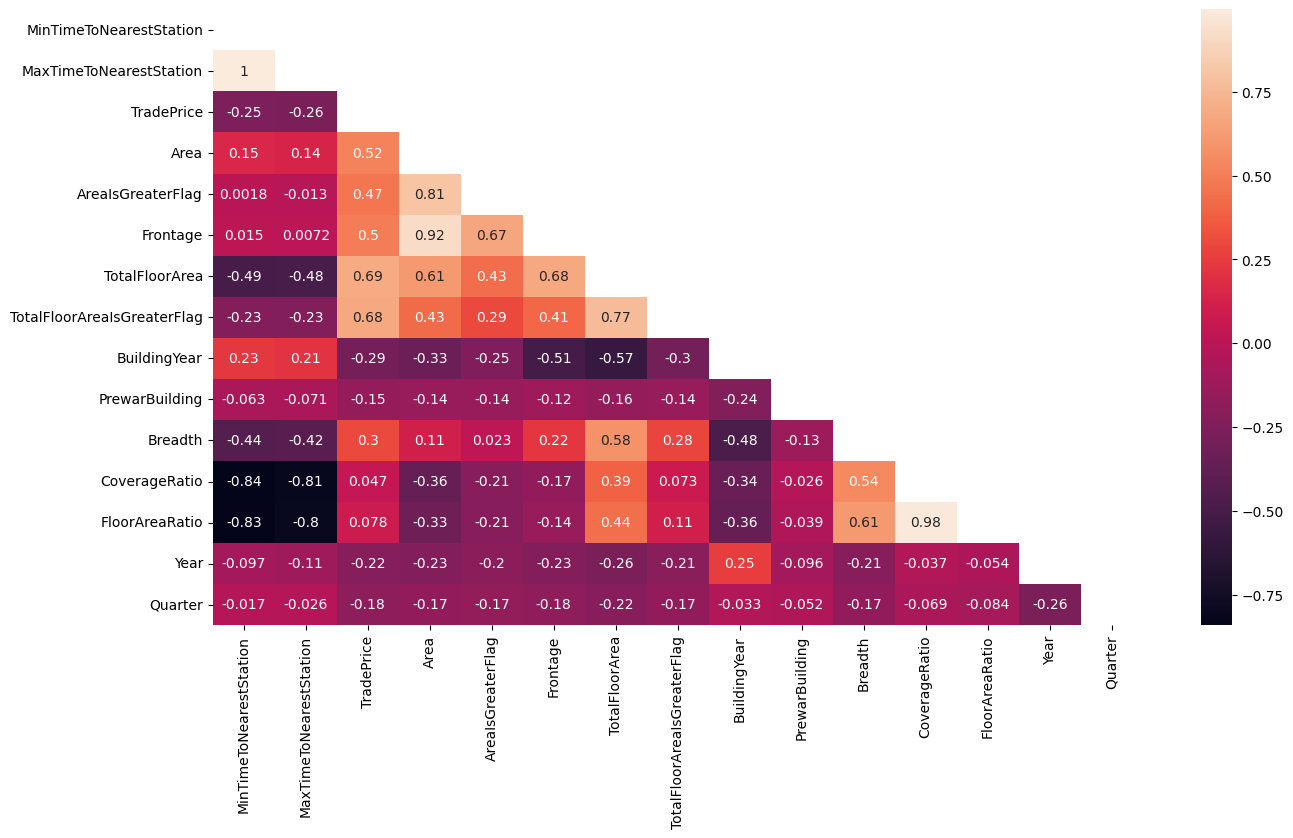

In [10]:
plot_heatmap(num_attributes)

Algumas observações interessantes que podem ser feitas em relação à variável TradePrice:
* Tamanho do imóvel (Area e TotalFloorArea) tem uma grande influência no preço;
* Largura da via de acesso ao imóvel influência no preço, indicando uma relação entre a acessibilidade e a valorização;
* Ano de construção do imóvel tem uma pequena correlação inversa com o preço, algo que parece contraditório. Geralmente se espera que imóveis mais novos sejam mais valorizados;
    * Isso pode acontecer por haver uma maior quantidade de prédios mais velhos que estão renovados e logo são valorizados por isso;
    * Vamos testar essa hipótese abaixo;

### Renovações por Ano

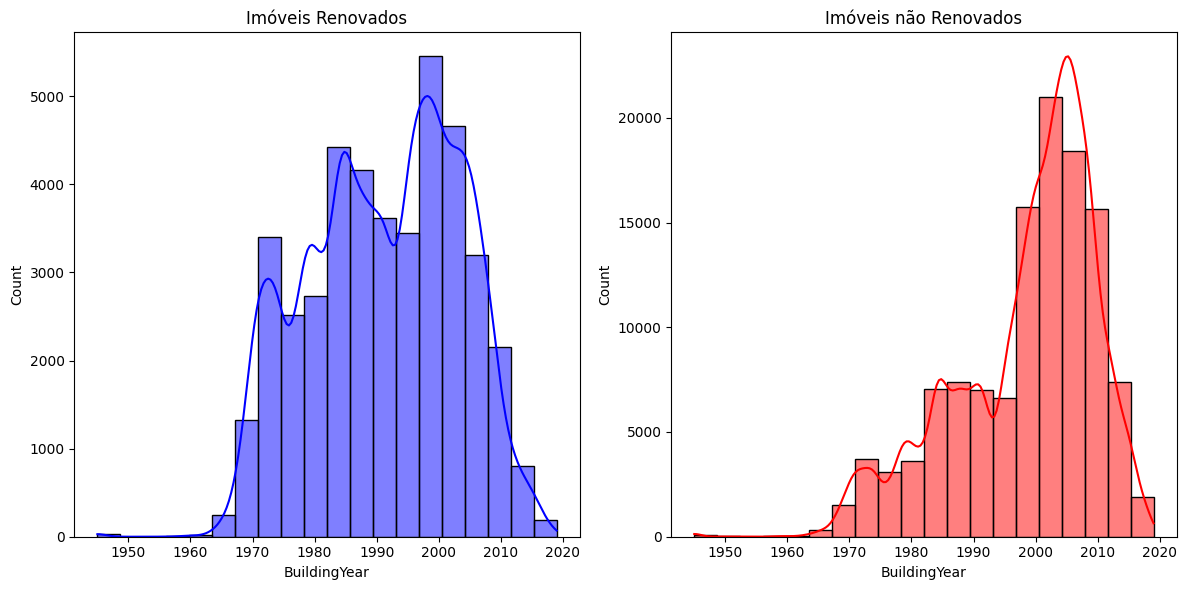

In [3]:
renewed = df.loc[df.Renovation == 'Done']
not_renewed = df.loc[df.Renovation == 'Not yet']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(data=renewed, x='BuildingYear', ax=axes[0], bins=20, color='blue', kde=True)
axes[0].set_title('Imóveis Renovados')

sns.histplot(data=not_renewed, x='BuildingYear', ax=axes[1], bins=20, color='red', kde=True)
axes[1].set_title('Imóveis não Renovados')

plt.tight_layout()
plt.show()

Podemos observar que uma significativa quantidade dos imóveis mais antigos que estão no mercado estão renovados;

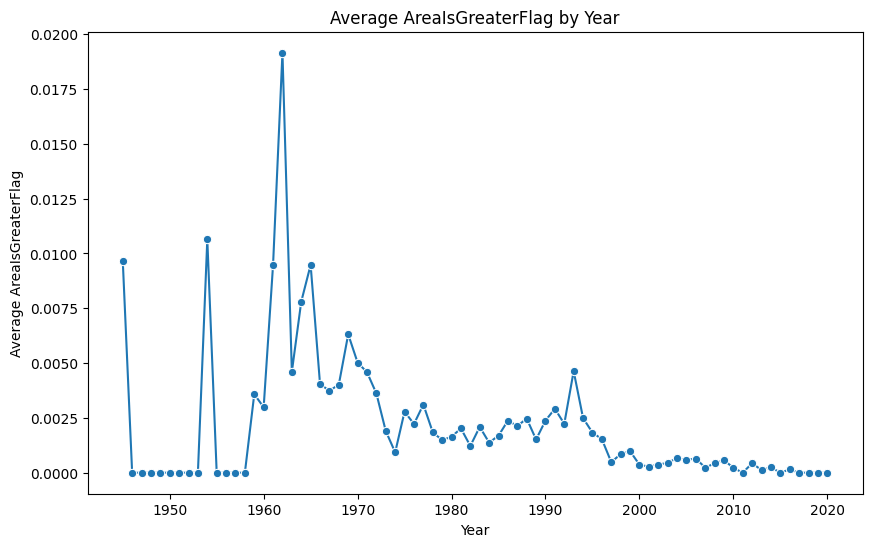

In [4]:
average_area_flag = df.groupby('BuildingYear')['AreaIsGreaterFlag'].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.lineplot(data=average_area_flag, x='BuildingYear', y='AreaIsGreaterFlag', marker='o')
plt.title('Average AreaIsGreaterFlag by Year')
plt.xlabel('Year')
plt.ylabel('Average AreaIsGreaterFlag')

plt.show()

Construções mais antigas também tendem a ter uma Área maior do que 2000m², i.e., são maiores do que construções mais recentes e isso influência mais no preço. Isso também pode ser observado na correlação de -0.33 entre BuildingYear e Area;

### TimeToNearestStation

In [11]:
df[df["TimeToNearestStation"]=="1H30-2H"][["MinTimeToNearestStation", "MaxTimeToNearestStation"]]

,MinTimeToNearestStation,MaxTimeToNearestStation
10375,90.0,120.0
92444,90.0,120.0
101954,90.0,120.0
112875,90.0,120.0
139015,90.0,120.0
...,...,...
396971,90.0,120.0
396974,90.0,120.0
397017,90.0,120.0
399734,90.0,120.0


TimeToNearestStation deveria ser a média entre MinTimeToNearestStation e MaxTimeToNearestStation. Essas duas variáveis estão formatadas corretamente em minutos. Porém, em alguns casos, o TimeToNearestStation está como um período no formato (MinTimetoNearestStation - MaxTimeToNearestStation);

Uma forma de corrigir isso é apenas fazer a média de MaxTimeToNearestStation e MinTimeToNearestStation para recriá-lo da forma correta;

In [12]:
df["TimeToNearestStation"] = (df["MinTimeToNearestStation"] + df["MaxTimeToNearestStation"])/2

Vamos plotar novamente o Heatmap:

In [13]:
num_attributes = df.select_dtypes(include=['int64', 'float64'])

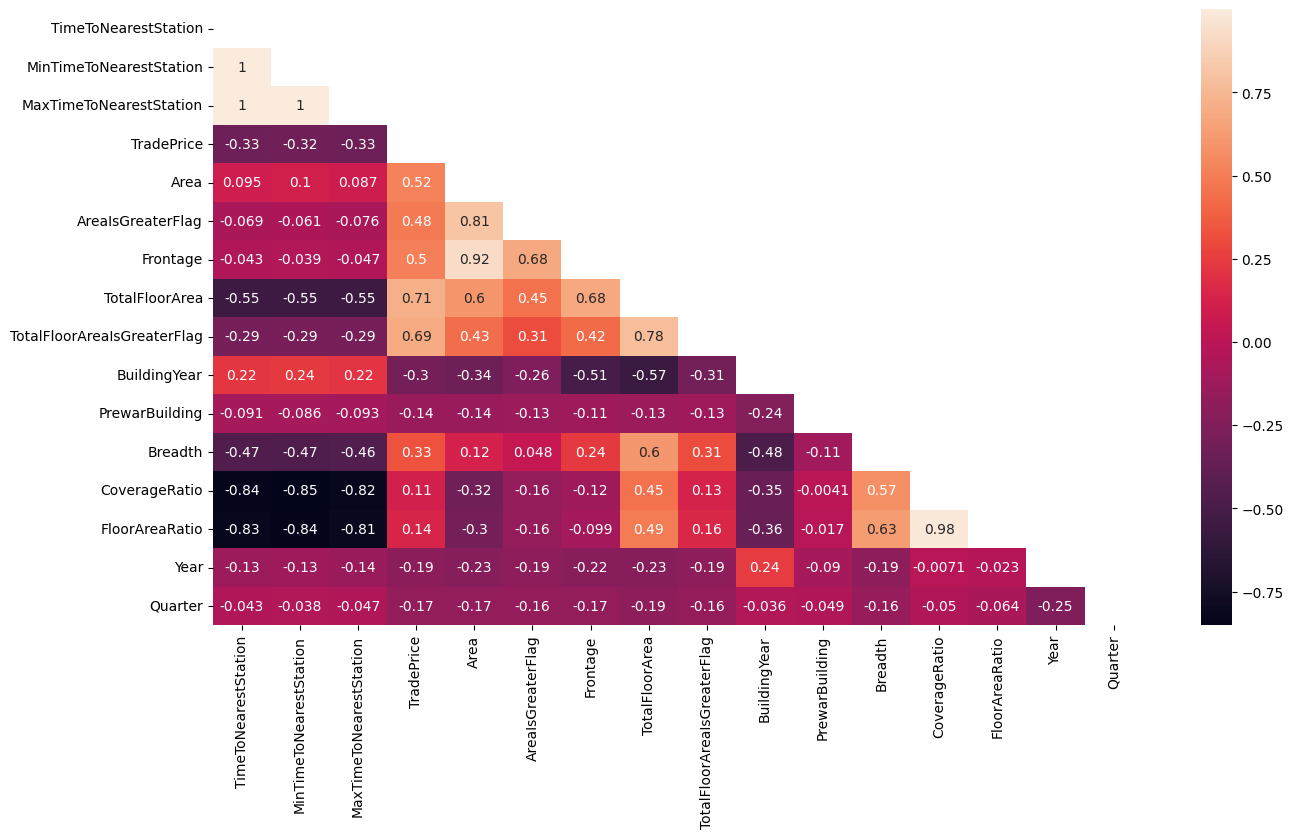

In [14]:
plot_heatmap(num_attributes)

Algumas variáveis com muita correlação com outras serão excluídas, mantendo aquelas com maior correlação com a variável alvo e/ou mantendo as que fazem mais sentido.

Para a variável Quarter vamos aplicar uma transformação cíclica, para capturar a sazonalidade trimestral.

In [15]:
cols = {'Quarter': 4, # quarter transformation
}

for period, cycle in cols.items():
    nature_encode(df, period, cycle)

In [16]:
df.columns

Index(['Type', 'Region', 'MunicipalityCode', 'Prefecture', 'Municipality',
       'DistrictName', 'NearestStation', 'TimeToNearestStation',
       'MinTimeToNearestStation', 'MaxTimeToNearestStation', 'TradePrice',
       'FloorPlan', 'Area', 'AreaIsGreaterFlag', 'LandShape', 'Frontage',
       'FrontageIsGreaterFlag', 'TotalFloorArea',
       'TotalFloorAreaIsGreaterFlag', 'BuildingYear', 'PrewarBuilding',
       'Structure', 'Use', 'Purpose', 'Direction', 'Classification', 'Breadth',
       'CityPlanning', 'CoverageRatio', 'FloorAreaRatio', 'Period', 'Year',
       'Quarter', 'Renovation', 'Quarter_sin', 'Quarter_cos'],
      dtype='object')

In [17]:
numerical_variables_selected = [
    "TimeToNearestStation",
    "Area",
    "BuildingYear",
    "CoverageRatio",
    "FloorAreaRatio",
    "Year",
    "Quarter_cos",
    "Quarter_sin",
]

In [18]:
df[numerical_variables_selected].isna().mean()

TimeToNearestStation    0.025798
Area                    0.000000
BuildingYear            0.226967
CoverageRatio           0.014548
FloorAreaRatio          0.014548
Year                    0.000000
Quarter_cos             0.000000
Quarter_sin             0.000000
dtype: float64

In [19]:
df[numerical_variables_selected]

,TimeToNearestStation,Area,BuildingYear,CoverageRatio,FloorAreaRatio,Year,Quarter_cos,Quarter_sin
0,4.0,30,2013.0,80.0,500.0,2019,-1.836970e-16,-1.000000e+00
1,4.0,80,2007.0,80.0,500.0,2019,-1.836970e-16,-1.000000e+00
2,2.0,110,2018.0,80.0,500.0,2019,-1.000000e+00,1.224647e-16
3,1.0,50,1976.0,80.0,700.0,2019,-1.000000e+00,1.224647e-16
4,4.0,65,2007.0,80.0,500.0,2019,-1.000000e+00,1.224647e-16
...,...,...,...,...,...,...,...,...
406570,NaN,500,NaN,70.0,200.0,2007,6.123234e-17,1.000000e+00
406571,NaN,115,NaN,70.0,200.0,2007,6.123234e-17,1.000000e+00
406572,NaN,230,NaN,70.0,200.0,2008,-1.836970e-16,-1.000000e+00
406573,NaN,175,NaN,70.0,200.0,2007,1.000000e+00,-2.449294e-16


### 2.2. Categorical Variables

In [20]:
cat_attributes = df.select_dtypes(exclude=['int64', 'float64', 'bool'])

In [21]:
cat_attributes.columns

Index(['Type', 'Region', 'MunicipalityCode', 'Prefecture', 'Municipality',
       'DistrictName', 'NearestStation', 'FloorPlan', 'LandShape',
       'FrontageIsGreaterFlag', 'Structure', 'Use', 'Purpose', 'Direction',
       'Classification', 'CityPlanning', 'Period', 'Renovation'],
      dtype='object')

In [22]:
cat_attributes.isna().mean().sort_values(ascending=False)

Purpose                  0.612049
Renovation               0.590479
FloorPlan                0.561874
Classification           0.461765
Direction                0.455746
LandShape                0.455692
Region                   0.454703
Use                      0.240755
Structure                0.216978
CityPlanning             0.009410
NearestStation           0.004250
Period                   0.000000
Type                     0.000000
DistrictName             0.000000
Municipality             0.000000
Prefecture               0.000000
MunicipalityCode         0.000000
FrontageIsGreaterFlag    0.000000
dtype: float64

In [23]:
cat_attributes[
    [
        "Type",
        "MunicipalityCode",
        "Municipality",
        "DistrictName",
        "CityPlanning",
    ]
]

,Type,MunicipalityCode,Municipality,DistrictName,CityPlanning
0,"Pre-owned Condominiums, etc.",13101,Chiyoda Ward,Iidabashi,Commercial Zone
1,"Pre-owned Condominiums, etc.",13101,Chiyoda Ward,Iidabashi,Commercial Zone
2,Residential Land(Land and Building),13101,Chiyoda Ward,Iidabashi,Commercial Zone
3,Residential Land(Land and Building),13101,Chiyoda Ward,Iidabashi,Commercial Zone
4,"Pre-owned Condominiums, etc.",13101,Chiyoda Ward,Iidabashi,Commercial Zone
...,...,...,...,...,...
406570,Residential Land(Land Only),13421,Ogasawara Village,Chichijima,Non-divided City Planning Area
406571,Residential Land(Land Only),13421,Ogasawara Village,Chichijima,Non-divided City Planning Area
406572,Residential Land(Land Only),13421,Ogasawara Village,Hahajima,Non-divided City Planning Area
406573,Residential Land(Land Only),13421,Ogasawara Village,Hahajima,Non-divided City Planning Area


In [ ]:
#TODO: Change locations.csv to a table in the database -> Populate it with geopy;

In [24]:
df_locations = pd.read_csv("locations.csv")
df = df.merge(df_locations, on="DistrictName", how="left")

In [25]:
categorical_variables_selected = [
    "Type", # tipo de residência, parece ser uma boa variável
    # "CityPlanning" # uso dos distritos pela lei de planejamento urbano, parece ser uma boa variável
    
]

In [26]:
df.columns

Index(['Type', 'Region', 'MunicipalityCode', 'Prefecture', 'Municipality',
       'DistrictName', 'NearestStation', 'TimeToNearestStation',
       'MinTimeToNearestStation', 'MaxTimeToNearestStation', 'TradePrice',
       'FloorPlan', 'Area', 'AreaIsGreaterFlag', 'LandShape', 'Frontage',
       'FrontageIsGreaterFlag', 'TotalFloorArea',
       'TotalFloorAreaIsGreaterFlag', 'BuildingYear', 'PrewarBuilding',
       'Structure', 'Use', 'Purpose', 'Direction', 'Classification', 'Breadth',
       'CityPlanning', 'CoverageRatio', 'FloorAreaRatio', 'Period', 'Year',
       'Quarter', 'Renovation', 'Quarter_sin', 'Quarter_cos', 'Latitude',
       'Longitude'],
      dtype='object')

In [27]:
categorical_variables_selected

['Type']

In [28]:
numerical_variables_selected.extend(['Latitude',
       'Longitude'])

In [29]:
numerical_variables_selected

['TimeToNearestStation',
 'Area',
 'BuildingYear',
 'CoverageRatio',
 'FloorAreaRatio',
 'Year',
 'Quarter_cos',
 'Quarter_sin',
 'Latitude',
 'Longitude']

# 3. Train-Test split

In [30]:
from sklearn.model_selection import train_test_split, cross_validate

Antes de qualquer outra modificação nos dados, vamos separar em treino e teste, para prevenir qualquer data leakage. Além disso, quando formos treinar os modelos, será utilizado cross-validation. 

In [31]:
# variaveis que serao usadas no modelo + variavel alvo (TradePrice) + DistrictName (que será usado pra tratar algumas variáveis nulas)
selected_variables = numerical_variables_selected + categorical_variables_selected + ["TradePrice", "DistrictName", "MunicipalityCode"] 

In [32]:
y = df["TradePrice"].copy()

In [33]:
X_train, X_test, y_train, y_test = train_test_split(df[selected_variables], y, test_size=0.2, random_state=0, shuffle=True)

# 4. Preprocessing

### 4.1. NaN treatment 

In [34]:
X_train[selected_variables]

,TimeToNearestStation,Area,BuildingYear,CoverageRatio,FloorAreaRatio,Year,Quarter_cos,Quarter_sin,Latitude,Longitude,Type,TradePrice,DistrictName,MunicipalityCode
3060,4.0,15,2004.0,80.0,700.0,2015,1.000000e+00,-2.449294e-16,35.675002,139.783445,"Pre-owned Condominiums, etc.",19000000,Shinkawa,13102
239670,8.0,25,2006.0,80.0,400.0,2008,1.000000e+00,-2.449294e-16,35.666255,139.775565,"Pre-owned Condominiums, etc.",13000000,Chuo,13114
165571,5.0,45,1992.0,60.0,300.0,2015,6.123234e-17,1.000000e+00,35.749219,139.715892,"Pre-owned Condominiums, etc.",28000000,Takinogawa,13117
218510,10.0,120,1985.0,40.0,80.0,2013,6.123234e-17,1.000000e+00,35.680048,139.619625,Residential Land(Land and Building),12000000,Takaidohigashi,13115
64370,12.0,60,2000.0,50.0,100.0,2014,1.000000e+00,-2.449294e-16,35.628006,139.673448,Residential Land(Land and Building),70000000,Kakinokizaka,13110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359783,NaN,560,NaN,NaN,NaN,2018,-1.000000e+00,1.224647e-16,34.069485,139.553822,Forest Land,340000,Tsubota,13381
358083,45.0,135,2016.0,50.0,100.0,2016,1.000000e+00,-2.449294e-16,35.778899,139.330760,Residential Land(Land and Building),22000000,Nagaoka,13303
152315,6.0,125,NaN,60.0,150.0,2006,6.123234e-17,1.000000e+00,35.653266,139.709595,Residential Land(Land Only),130000000,Higashigotanda,13109
117952,7.0,55,2005.0,80.0,200.0,2005,1.000000e+00,-2.449294e-16,35.700379,139.805867,Residential Land(Land and Building),41000000,Sumida,13107


In [35]:
X_train[selected_variables].isna().mean().sort_values(ascending=False)

BuildingYear            0.226794
Latitude                0.104984
Longitude               0.104984
TimeToNearestStation    0.026028
CoverageRatio           0.014471
FloorAreaRatio          0.014471
Area                    0.000000
Year                    0.000000
Quarter_cos             0.000000
Quarter_sin             0.000000
Type                    0.000000
TradePrice              0.000000
DistrictName            0.000000
MunicipalityCode        0.000000
dtype: float64

- **BuildingYear**: Substituir pela média do ano, agrupado por DistrictName
- **TimeToNearestStation**: Substituir pela mediana do ano, agrupado por DistrictName
- **CoverageRatio**: Substituir pela mediana do ano, agrupado por DistrictName
- **FloorAreaRatio**: Substituir pela mediana do ano, agrupado por DistrictName
- **Latitude**: Substituir pela mediana do ano, agrupado por MunicipalityCode
- **Longitude**: Substituir pela mediana do ano, agrupado por MunicipalityCode

Obs: Para o Latitude e Longitude foi agrupado por MunicipalityCode, porque é justamente o DistrictName que gera essas colunas, e se está nuilo seguirá nulo obviamente.

In [36]:
X_train[selected_variables].isna().mean().sort_values(ascending=False)

BuildingYear            0.226794
Latitude                0.104984
Longitude               0.104984
TimeToNearestStation    0.026028
CoverageRatio           0.014471
FloorAreaRatio          0.014471
Area                    0.000000
Year                    0.000000
Quarter_cos             0.000000
Quarter_sin             0.000000
Type                    0.000000
TradePrice              0.000000
DistrictName            0.000000
MunicipalityCode        0.000000
dtype: float64

In [37]:
X_train["BuildingYear"] = X_train["BuildingYear"].fillna(
    X_train.groupby("DistrictName")["BuildingYear"].transform("mean")
)
X_train["TimeToNearestStation"] = X_train["TimeToNearestStation"].fillna(
    X_test.groupby("DistrictName")["TimeToNearestStation"].transform("median")
)
X_train["CoverageRatio"] = X_train["CoverageRatio"].fillna(
    X_train.groupby("DistrictName")["CoverageRatio"].transform("median")
)
X_train["FloorAreaRatio"] = X_train["FloorAreaRatio"].fillna(
    X_train.groupby("DistrictName")["FloorAreaRatio"].transform("median")
)
X_train["Latitude"] = X_train["Latitude"].fillna(
    X_train.groupby("MunicipalityCode")["Latitude"].transform("median")
)
X_train["Longitude"] = X_train["Longitude"].fillna(
    X_train.groupby("MunicipalityCode")["Longitude"].transform("median")
)

In [38]:
X_train[selected_variables].isna().mean().sort_values(ascending=False)

TimeToNearestStation    0.026028
Latitude                0.001257
Longitude               0.001257
CoverageRatio           0.000443
FloorAreaRatio          0.000443
BuildingYear            0.000209
Area                    0.000000
Year                    0.000000
Quarter_cos             0.000000
Quarter_sin             0.000000
Type                    0.000000
TradePrice              0.000000
DistrictName            0.000000
MunicipalityCode        0.000000
dtype: float64

Ainda temos alguns valores nulos, para esses casos vamos só substituir pela mediana da coluna mesmo:

In [39]:
X_train["BuildingYear"] = X_train["BuildingYear"].fillna(
    X_train["BuildingYear"].median()
)
X_train["TimeToNearestStation"] = X_train["TimeToNearestStation"].fillna(
    X_train["TimeToNearestStation"].median()
)
X_train["Latitude"] = X_train["Latitude"].fillna(X_train["Latitude"].median())
X_train["Longitude"] = X_train["Longitude"].fillna(X_train["Longitude"].median())
X_train["CoverageRatio"] = X_train["CoverageRatio"].fillna(
    X_train["CoverageRatio"].median()
)
X_train["FloorAreaRatio"] = X_train["FloorAreaRatio"].fillna(
    X_train["FloorAreaRatio"].median()
)

In [40]:
X_train[selected_variables].isna().mean().sort_values(ascending=False)

TimeToNearestStation    0.0
Area                    0.0
BuildingYear            0.0
CoverageRatio           0.0
FloorAreaRatio          0.0
Year                    0.0
Quarter_cos             0.0
Quarter_sin             0.0
Latitude                0.0
Longitude               0.0
Type                    0.0
TradePrice              0.0
DistrictName            0.0
MunicipalityCode        0.0
dtype: float64

### 4.2. Variables Encoding (normalization/scaling)

In [41]:
cols = [
    "TimeToNearestStation",
    "Area",
    "BuildingYear",
    "CoverageRatio",
    "FloorAreaRatio",
    "Year",
    "Quarter_cos",
    "Quarter_sin",
    "Latitude",
    "Longitude",
    "Type",
]
X_train = X_train[cols]

### Categorical

In [42]:
one_hot = pd.get_dummies(X_train["Type"], drop_first=True, prefix="Type", dtype=int)
X_train = X_train.join(one_hot).drop("Type", axis=1)

### Numerical

Obs: Para os três modelos que vamos utilizar não é necessário normalizar as variáveis: Random Forest, XGBoost e LGBM, mas é interessante fazermos esse processo se fossemos utilizar uma rede neural, por exemplo.

In [43]:
scaler_nearest_station = MinMaxScaler()
scaler_area = MinMaxScaler()
scaler_building_year = MinMaxScaler()
scaler_coverage = MinMaxScaler()
scaler_floor = MinMaxScaler()
scaler_year = MinMaxScaler()
scaler_lat = MinMaxScaler()
scaler_long = MinMaxScaler()

X_train["TimeToNearestStation"] = scaler_nearest_station.fit_transform(X_train[["TimeToNearestStation"]])
X_train["Area"] = scaler_area.fit_transform(X_train[["Area"]])
X_train["BuildingYear"] = scaler_building_year.fit_transform(X_train[["BuildingYear"]])
X_train["CoverageRatio"] = scaler_coverage.fit_transform(X_train[["CoverageRatio"]])
X_train["FloorAreaRatio"] = scaler_floor.fit_transform(X_train[["FloorAreaRatio"]])
X_train["Year"] = scaler_year.fit_transform(X_train[["Year"]])
X_train["Latitude"] = scaler_lat.fit_transform(X_train[["Latitude"]])
X_train["Longitude"] = scaler_long.fit_transform(X_train[["Longitude"]])

In [44]:
X_train

,TimeToNearestStation,Area,BuildingYear,CoverageRatio,FloorAreaRatio,Year,Quarter_cos,Quarter_sin,Latitude,Longitude,Type_Forest Land,"Type_Pre-owned Condominiums, etc.",Type_Residential Land(Land Only),Type_Residential Land(Land and Building)
3060,0.038095,0.001002,0.786667,1.0,0.520,0.714286,1.000000e+00,-2.449294e-16,0.813453,0.829528,0,1,0,0
239670,0.076190,0.003006,0.813333,1.0,0.280,0.214286,1.000000e+00,-2.449294e-16,0.812669,0.828974,0,1,0,0
165571,0.047619,0.007014,0.626667,0.6,0.200,0.714286,6.123234e-17,1.000000e+00,0.820110,0.824781,0,1,0,0
218510,0.095238,0.022044,0.533333,0.2,0.024,0.571429,6.123234e-17,1.000000e+00,0.813906,0.818017,0,0,0,1
64370,0.114286,0.010020,0.733333,0.4,0.040,0.642857,1.000000e+00,-2.449294e-16,0.809239,0.821799,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359783,0.076190,0.110220,0.474286,0.8,0.120,0.928571,-1.000000e+00,1.224647e-16,0.669459,0.813394,1,0,0,0
358083,0.428571,0.025050,0.946667,0.4,0.040,0.785714,1.000000e+00,-2.449294e-16,0.822772,0.797720,0,0,0,1
152315,0.057143,0.023046,0.737579,0.6,0.080,0.071429,6.123234e-17,1.000000e+00,0.811504,0.824339,0,0,1,0
117952,0.066667,0.009018,0.800000,1.0,0.120,0.000000,1.000000e+00,-2.449294e-16,0.815729,0.831104,0,0,0,1


In [45]:
X_train.isna().sum()

TimeToNearestStation                        0
Area                                        0
BuildingYear                                0
CoverageRatio                               0
FloorAreaRatio                              0
Year                                        0
Quarter_cos                                 0
Quarter_sin                                 0
Latitude                                    0
Longitude                                   0
Type_Forest Land                            0
Type_Pre-owned Condominiums, etc.           0
Type_Residential Land(Land Only)            0
Type_Residential Land(Land and Building)    0
dtype: int64

### Target Variable

In [46]:
y_train = np.log1p(y_train) # Logarithm Transformation

# 5. Model Training

In [47]:
# Converter pra snake_case, porque alguns modelos não aceitam caracteres especiais
X_train.columns = [
    'time_to_nearest_station', 'area', 'building_year', 'coverage_ratio',
    'floor_area_ratio', 'year', 'quarter_cos', 'quarter_sin', 'latitude',
    'longitude', 'type_forest_land', 'type_pre_owned_condominiums_etc',
    'type_residential_land_land_only',
    'type_residential_land_land_and_building'
]


Reduzindo o número de variáveis, usando Random Forest como um seletor de variáveis

In [48]:
# rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
# rf.fit(X_train, y_train)

# importances = rf.feature_importances_

# feature_importances = pd.DataFrame({
#     'feature': X_train.columns,
#     'importance': importances
# })

# feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# print(feature_importances)

In [49]:
# final_selected_variables = [
#     "time_to_nearest_station",
#     "area",
#     "building_year",
#     "floor_area_ratio",
#     "year",
#     "latitude",
#     "longitude",
# ]


In [50]:
# X_train = X_train[final_selected_variables]

A classe `OptimizeRegressor` consegue otimizar 3 modelos diferentes: RandomForest, XGBoost e LGBM, salvando depois os melhores parâmetros num `json`.

Obs: A otimização é feita com base na métrica `RMSLE`, avaliando com cross-validation (K_fold=5)

### 5.1. Hyperparameter Optimization with Cross-Validation

### Random Forest

In [51]:
# rf_opt = OptimizeRegressor(
#     model_name="rf", n_trials=20, X_train=X_train, y_train=y_train
# )

# rf_opt.optimize()

### XGBoost

0.02000 - xgb_best_params_14_features.json

In [52]:
xgb_opt = OptimizeRegressor(
    model_name="xgb", n_trials=30, X_train=X_train, y_train=y_train
)

xgb_opt.optimize()

[I 2024-05-17 16:04:18,508] A new study created in memory with name: no-name-86461f38-7cd2-49ec-a392-986b809e3b2a
[I 2024-05-17 16:04:38,471] Trial 0 finished with value: 0.021017730550045584 and parameters: {'n_estimators': 1100, 'learning_rate': 0.065, 'max_depth': 5, 'min_child_weight': 7, 'subsample': 0.6, 'colsample_bytree': 0.95}. Best is trial 0 with value: 0.021017730550045584.
[I 2024-05-17 16:06:37,403] Trial 1 finished with value: 0.02063857357312524 and parameters: {'n_estimators': 2800, 'learning_rate': 0.075, 'max_depth': 10, 'min_child_weight': 2, 'subsample': 0.95, 'colsample_bytree': 0.7}. Best is trial 1 with value: 0.02063857357312524.
[I 2024-05-17 16:06:55,014] Trial 2 finished with value: 0.02051614229150347 and parameters: {'n_estimators': 1300, 'learning_rate': 0.06999999999999999, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.6, 'colsample_bytree': 0.8}. Best is trial 2 with value: 0.02051614229150347.
[I 2024-05-17 16:07:53,618] Trial 3 finished with v

### LGBM

In [53]:
lgbm_opt = OptimizeRegressor(
    model_name="lgbm", n_trials=30, X_train=X_train, y_train=y_train
)
lgbm_opt.optimize()

[I 2024-05-17 15:42:21,654] A new study created in memory with name: no-name-fcd0fe00-3e1f-43e9-8157-10c3b13d2a40
[I 2024-05-17 15:43:48,742] Trial 0 finished with value: 0.02056402592074822 and parameters: {'n_estimators': 2700, 'learning_rate': 0.01, 'max_depth': 9, 'num_leaves': 100}. Best is trial 0 with value: 0.02056402592074822.
[I 2024-05-17 15:44:01,295] Trial 1 finished with value: 0.022630141555725746 and parameters: {'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 12, 'num_leaves': 80}. Best is trial 0 with value: 0.02056402592074822.
[I 2024-05-17 15:44:29,749] Trial 2 finished with value: 0.02021614029134565 and parameters: {'n_estimators': 1200, 'learning_rate': 0.04, 'max_depth': 12, 'num_leaves': 124}. Best is trial 2 with value: 0.02021614029134565.
[I 2024-05-17 15:45:09,491] Trial 3 finished with value: 0.02013437868731533 and parameters: {'n_estimators': 2400, 'learning_rate': 0.04, 'max_depth': 10, 'num_leaves': 84}. Best is trial 3 with value: 0.02013437

### 5.2. Fitting the best model

### Random Forest

In [ ]:
# rf_best_params = read_json("/parameters/best_params_rf.json")
# rf_best_params["verbose"] = -1
# rf_best_params["n_jobs"] = -1
# rf_best_params["random_state"] = 42

### XGBoost

In [ ]:
xgb_best_params = read_json("/parameters/best_params_xgb.json")
xgb_best_params["n_jobs"] = -1
xgb_best_params["random_state"] = 42

In [54]:
xgb_model = XGBRegressor(**xgb_best_params)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.75, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.035, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1300, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

### LGBM

In [ ]:
lgbm_best_params = read_json("/parameters/best_params_lgbm.json")
lgbm_best_params["verbosity"] = -1
lgbm_best_params["n_jobs"] = -1
lgbm_best_params["random_state"] = 42

In [55]:
model = LGBMRegressor(**lgbm_best_params)
model.fit(X_train, y_train)

LGBMRegressor(learning_rate=0.05, max_depth=10, n_estimators=2600, n_jobs=-1,
              num_leaves=112, random_state=42, verbosity=-1)

#### Testar remover algumas variáveis

- Temos 14 colunas, o que é bastante pro volume de dados.

# Evaluating results in Test

Precisa aplicar novamente o mesmo processamento que foi feito para X_train.

In [55]:
X_test["BuildingYear"] = X_test["BuildingYear"].fillna(
    X_test.groupby("DistrictName")["BuildingYear"].transform("mean")
)
X_test["TimeToNearestStation"] = X_test["TimeToNearestStation"].fillna(
    X_test.groupby("DistrictName")["TimeToNearestStation"].transform("median")
)
X_test["CoverageRatio"] = X_test["CoverageRatio"].fillna(
    X_test.groupby("DistrictName")["CoverageRatio"].transform("median")
)
X_test["FloorAreaRatio"] = X_test["FloorAreaRatio"].fillna(
    X_test.groupby("DistrictName")["FloorAreaRatio"].transform("median")
)
X_test["Latitude"] = X_test["Latitude"].fillna(
    X_test.groupby("MunicipalityCode")["Latitude"].transform("median")
)
X_test["Longitude"] = X_test["Longitude"].fillna(
    X_test.groupby("MunicipalityCode")["Longitude"].transform("median")
)

In [56]:
X_test["BuildingYear"] = X_test["BuildingYear"].fillna(
    X_test["BuildingYear"].median()
)
X_test["TimeToNearestStation"] = X_test["TimeToNearestStation"].fillna(
    X_test["TimeToNearestStation"].median()
)
X_test["Latitude"] = X_test["Latitude"].fillna(X_test["Latitude"].median())
X_test["Longitude"] = X_test["Longitude"].fillna(X_test["Longitude"].median())
X_test["CoverageRatio"] = X_test["CoverageRatio"].fillna(
    X_test["CoverageRatio"].median()
)
X_test["FloorAreaRatio"] = X_test["FloorAreaRatio"].fillna(
    X_test["FloorAreaRatio"].median()
)

In [57]:
cols = [
    "TimeToNearestStation",
    "Area",
    "BuildingYear",
    "CoverageRatio",
    "FloorAreaRatio",
    "Year",
    "Quarter_cos",
    "Quarter_sin",
    "Latitude",
    "Longitude",
    "Type",
]
X_test = X_test[cols]

In [58]:
one_hot = pd.get_dummies(X_test["Type"], drop_first=True, prefix="Type", dtype=int)
X_test = X_test.join(one_hot).drop("Type", axis=1)

In [59]:
scaler_nearest_station = MinMaxScaler()
scaler_area = MinMaxScaler()
scaler_building_year = MinMaxScaler()
scaler_coverage = MinMaxScaler()
scaler_floor = MinMaxScaler()
scaler_year = MinMaxScaler()
scaler_lat = MinMaxScaler()
scaler_long = MinMaxScaler()

X_test["TimeToNearestStation"] = scaler_nearest_station.fit_transform(X_test[["TimeToNearestStation"]])
X_test["Area"] = scaler_area.fit_transform(X_test[["Area"]])
X_test["BuildingYear"] = scaler_building_year.fit_transform(X_test[["BuildingYear"]])
X_test["CoverageRatio"] = scaler_coverage.fit_transform(X_test[["CoverageRatio"]])
X_test["FloorAreaRatio"] = scaler_floor.fit_transform(X_test[["FloorAreaRatio"]])
X_test["Year"] = scaler_year.fit_transform(X_test[["Year"]])
X_test["Latitude"] = scaler_lat.fit_transform(X_test[["Latitude"]])
X_test["Longitude"] = scaler_long.fit_transform(X_test[["Longitude"]])

In [60]:
# Converter pra snake_case, porque alguns modelos não aceitam caracteres especiais
X_test.columns = [
    'time_to_nearest_station', 'area', 'building_year', 'coverage_ratio',
    'floor_area_ratio', 'year', 'quarter_cos', 'quarter_sin', 'latitude',
    'longitude', 'type_forest_land', 'type_pre_owned_condominiums_etc',
    'type_residential_land_land_only',
    'type_residential_land_land_and_building'
]


In [61]:
y_test = np.log1p(y_test) # Logarithm Transformation 

In [65]:
# X_test = X_test[final_selected_variables]

### **Predict**

In [63]:
predictions = xgb_model.predict(X_test)

In [64]:
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

In [65]:
# Voltando aos valores
comparison_df = comparison_df.assign(Actual=np.expm1(comparison_df['Actual']))
comparison_df = comparison_df.assign(Predicted=np.expm1(comparison_df['Predicted']))

In [66]:
comparison_df

,Actual,Predicted
164964,57000000.0,50416272.0
405628,18000000.0,16394887.0
36359,7000000.0,7555653.0
358112,16000000.0,13949742.0
396468,66000000.0,61091608.0
...,...,...
219310,36000000.0,26320316.0
322488,38000000.0,39806632.0
6057,45000000.0,32722690.0
38678,57000000.0,71520248.0


### Test Result

In [67]:
mape = mean_absolute_percentage_error(comparison_df["Actual"], comparison_df["Predicted"])
rmsle = np.sqrt(mean_squared_log_error(comparison_df["Actual"], comparison_df["Predicted"]))

In [68]:
# novo - xgboost
print(f"mape = {mape}")
print(f"rmsle = {rmsle}")

mape = 0.3945776229607925
rmsle = 0.3488141026159459


In [68]:
# novo - lgbm
print(f"mape = {mape}")
print(f"rmsle = {rmsle}")

mape = 0.5061042842893033
rmsle = 0.38223049708257556


In [65]:
print(f"mape = {mape}")
print(f"rmsle = {rmsle}")

mape = 0.3819359979784899
rmsle = 0.38348949713450664


In [60]:
comparison_df

,Actual,Predicted
164964,57000000.0,5.048309e+07
405628,18000000.0,1.735935e+07
36359,7000000.0,6.362006e+06
358112,16000000.0,1.017839e+07
396468,66000000.0,4.406585e+07
...,...,...
219310,36000000.0,2.777936e+07
322488,38000000.0,2.789517e+07
6057,45000000.0,3.161022e+07
38678,57000000.0,7.226326e+07
